In [14]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv(r"C:\Users\R5b\Downloads\archive\stroke_preprocessed.csv")
df = pd.get_dummies(df, drop_first=True)

X = df.drop("stroke", axis=1)
y = df["stroke"]

X_train,X_test,y_train,y_test=train_test_split(X, y, test_size=0.2, random_state=42)

model = DecisionTreeRegressor(random_state=42)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse=mean_squared_error(y_test, y_pred)
r2=r2_score(y_test, y_pred)

print("Mean Squared Error:",mse)
print("R2 score:", r2)

result=pd.DataFrame({"actual":y_test.values, "predicted": y_pred})
print()
print(result)




Mean Squared Error: 0.09980430528375733
R2 score: -0.7514112903225814

      actual  predicted
0          0        0.0
1          0        0.0
2          0        0.0
3          0        0.0
4          0        0.0
...      ...        ...
1017       0        0.0
1018       0        0.0
1019       0        0.0
1020       0        0.0
1021       0        0.0

[1022 rows x 2 columns]


Accuracy Score: 0.9447162426614482

Confusion Matrix: [[3856   26]
 [ 200    6]]

Classification Report:               precision    recall  f1-score   support

           0       0.95      0.99      0.97      3882
           1       0.19      0.03      0.05       206

    accuracy                           0.94      4088
   macro avg       0.57      0.51      0.51      4088
weighted avg       0.91      0.94      0.93      4088



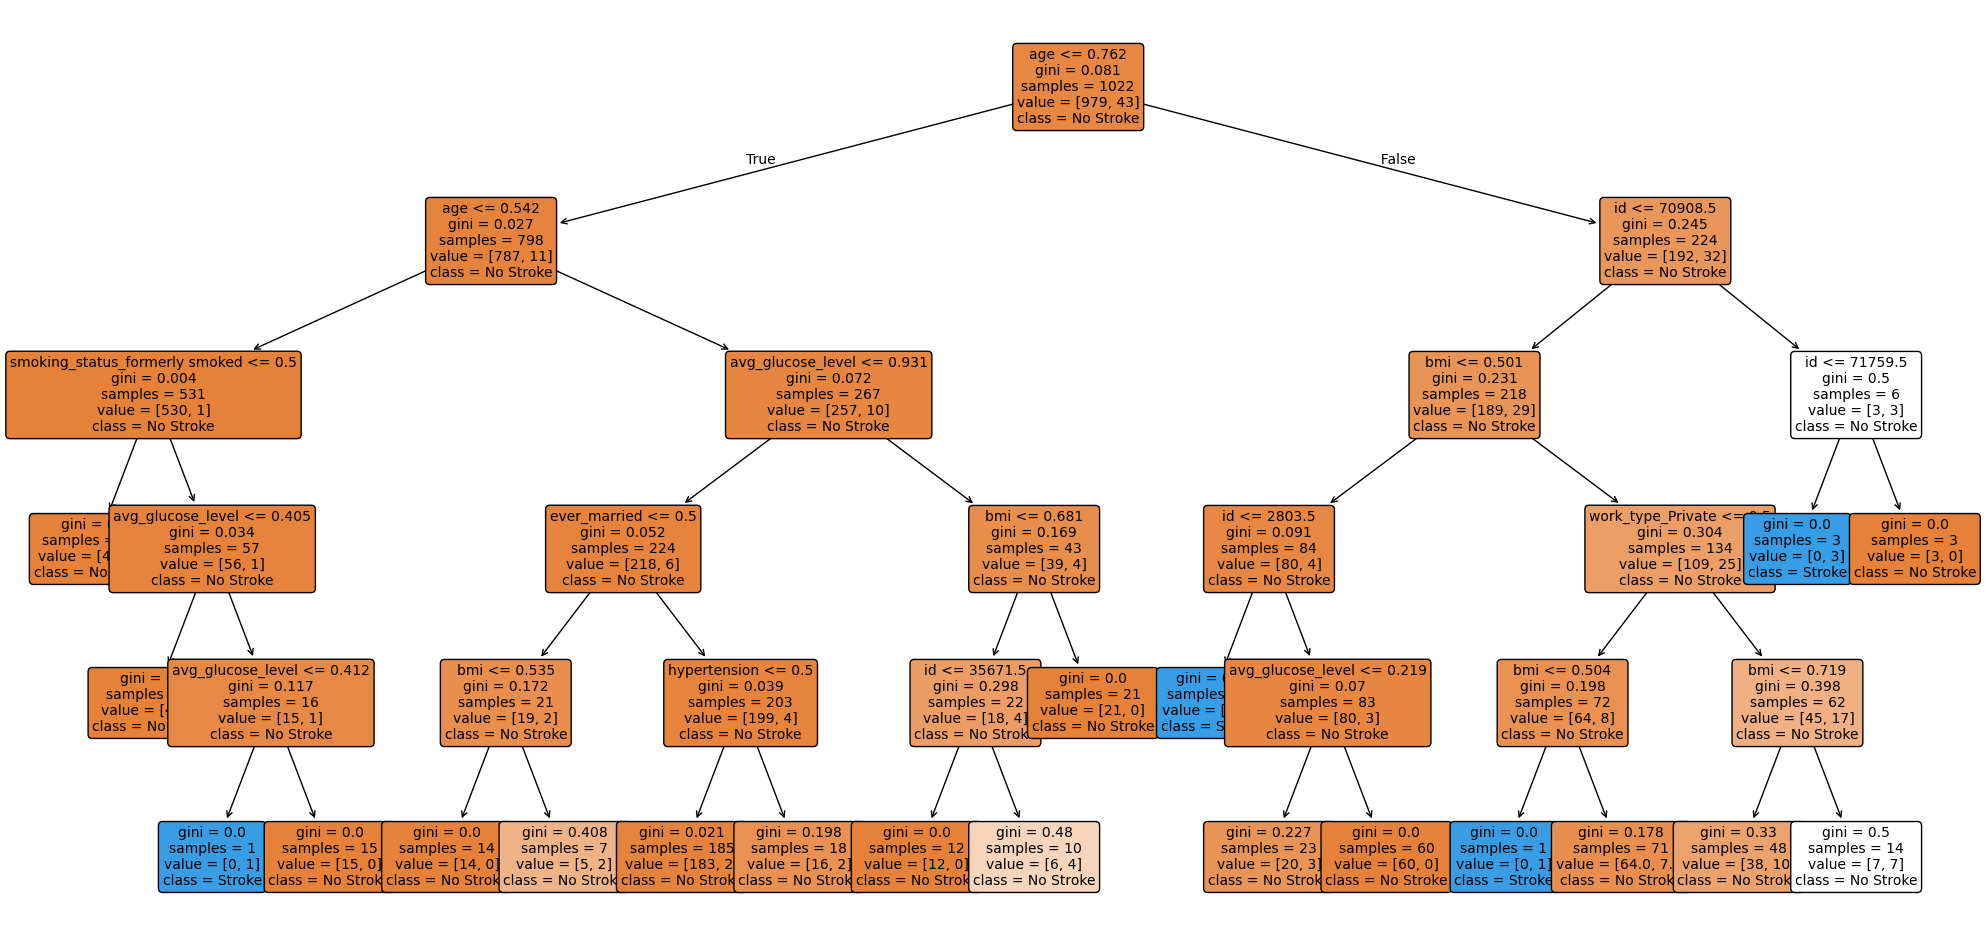

In [36]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree  #Visualise the model

df = pd.read_csv(r"C:\Users\R5b\Downloads\archive\stroke_preprocessed.csv")
df=pd.get_dummies(df, drop_first=True)

X = df.drop("stroke", axis=1)
y = df["stroke"]

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.2, random_state=42)

model= DecisionTreeClassifier(criterion="gini",max_depth=5, random_state=42)

model.fit(X_train, y_train)

y_pred=model.predict(X_test)

a=accuracy_score(y_test, y_pred)
cm=confusion_matrix(y_test, y_pred)
r=classification_report(y_test, y_pred)

print("Accuracy Score:", a)
print("\nConfusion Matrix:", cm)
print("\nClassification Report:", r)

plt.figure(figsize=(25,12))

plot_tree(model, feature_names=X.columns, class_names=["No Stroke", "Stroke"], filled=True, rounded=True, fontsize=10)
plt.show()       